In [1]:
import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
data_path = Path("..") / "data/engineered/training_pop30_genres.parquet"
df = pd.read_parquet(data_path)
print(f"Loaded {len(df):,} tracks from {data_path}")

Loaded 1,862,314 tracks from ../data/engineered/training_pop30_genres.parquet


# Data prep

## Categorical columns

In [4]:
from ast import literal_eval


df = df.astype(
    {
        "key": "category",
        "time_signature": "category",
        "release_season": "category",
        "album_type": "category",
    }
)
if pd.api.types.is_string_dtype(df["_artist_genres"]):
    df["_artist_genres"] = df["_artist_genres"].map(literal_eval)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862314 entries, 0 to 1862313
Data columns (total 26 columns):
 #   Column            Dtype   
---  ------            -----   
 0   track_rowid       int64   
 1   track_name        string  
 2   artist_name       string  
 3   artist_rowid      int64   
 4   album_rowid       int64   
 5   album_name        string  
 6   _label            string  
 7   artist_genres     string  
 8   _artist_genres    object  
 9   album_type        category
 10  release_season    category
 11  key               category
 12  time_signature    category
 13  mode              bool    
 14  tempo             float32 
 15  release_year      int32   
 16  danceability      float32 
 17  energy            float32 
 18  loudness          float32 
 19  speechiness       float32 
 20  acousticness      float32 
 21  instrumentalness  float32 
 22  liveness          float32 
 23  valence           float32 
 24  explicit          bool    
 25  duration_ms       

## Indexing labels

In [6]:
def build_label_vocab(labels: pd.Series):
    vocab = {}
    for label in labels.value_counts().index:
        if label not in vocab:
            vocab[label] = len(vocab)
    return vocab

label2idx = build_label_vocab(df["_label"])
print(f"Found {len(label2idx)} unique labels.")

Found 8363 unique labels.


## Indexing genre

In [7]:
from ast import literal_eval

def build_genre_vocab(genres: pd.Series):
    vocab = {}
    for genres in genres:
        for genre in genres:
            if genre not in vocab:
                vocab[genre] = len(vocab)
    return vocab

genre2idx = build_genre_vocab(df["_artist_genres"])
print(f"Found {len(genre2idx)} genres.")

Found 668 genres.


## Test-train split

In [8]:
ntrain = int(0.8 * len(df)); nvalid = len(df) - ntrain
_shuffled = df.sample(frac=1, replace=False, ignore_index=True, random_state=0)
dft = _shuffled.iloc[:ntrain].reset_index(drop=True)
dfv = _shuffled.iloc[ntrain:].reset_index(drop=True)

## Numerical feature standardization

In [9]:
def minmax(s: pd.Series, r: pd.Series | None=None, vrange:tuple[int, int]=(0, 1)) -> pd.Series:
    if r is None:
        r = s
    a, b = vrange
    return a + (s - r.min()) * (b - a) / (r.max() - r.min())

def zscore(s: pd.Series, r: pd.Series | None=None, mode: str = "mean"):
    if r is None:
        r = s
    if mode == "mean":
        m = r.mean()
    elif mode == "median":
        m = r.median()
    else:
        raise ValueError()
    return (s - m) / r.std()


ZSCORE_COLS = ["tempo", "duration_ms", "danceability", "energy", "loudness", "liveness", "valence"]
MINMAX_COLS = ["release_year", "speechiness", "acousticness", "instrumentalness"]

for col in ZSCORE_COLS:
  dfv[col] = zscore(dfv[col], dft[col], mode="median")
  dft[col] = zscore(dft[col], mode="median")

for col in MINMAX_COLS:
  dfv[col] = minmax(dfv[col], dft[col], vrange=(-1., 1.))
  dft[col] = minmax(dft[col], vrange=(-1., 1.))

In [10]:
if (_plot_train_correlations := False):
    features = [
        "tempo", "duration_ms", "release_year", "danceability", "energy",
        "loudness", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence",
    ]
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, n_feat, figsize=(12,12))
    
    for i in range(n_feat):
        for j in range(n_feat):
            ax = axes[i, j]
            if i == j:
                ax.hist(dft[features[i]], bins=30, color='steelblue', edgecolor='white')
            else:
                ax.hist2d(dft[features[j]], dft[features[i]], bins=30)
            
            if i == n_feat - 1:
                ax.set_xlabel(features[j], rotation=45, ha='right')
                ax.tick_params(axis='x', labelsize=7, rotation=45)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(features[i])
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Dataset

In [11]:
import torch
from torch.utils.data import Dataset
from torch.nn.functional import one_hot


class TrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label2idx: dict[str, int], genre2idx: dict[str, int]):
        # one-hot encoded
        self.album_type = one_hot(torch.tensor(df["album_type"].cat.codes.values, dtype=torch.long))
        self.release_season = one_hot(torch.tensor(df["release_season"].cat.codes.values, dtype=torch.long))
        self.time_signature = one_hot(torch.tensor(df["time_signature"].cat.codes.values, dtype=torch.long))
        self.key = one_hot(torch.tensor(df["key"].cat.codes.values, dtype=torch.long))
        # labels
        self.label = torch.tensor(df["_label"].map(label2idx).values, dtype=torch.long)
        # genres multi-hot
        self.genres = torch.zeros(len(df), len(genre2idx), dtype=torch.float32) # float32, it will feed a layer embedding
        for i, gs in enumerate(df["_artist_genres"]):
            for g in gs:
                self.genres[i, genre2idx[g]] = 1.
        # float variables
        self.floats = torch.tensor(
            df[[
                "release_year",
                "tempo",
                "danceability",
                "energy",
                "loudness",
                "speechiness",
                "acousticness",
                "instrumentalness",
                "liveness",
                "valence",
                "duration_ms",
            ]].values, 
            dtype=torch.float32
        )
        # bool variables
        self.bools = torch.tensor(
            df[[
                "mode",
                "explicit",
            ]].values,
            dtype=torch.float,
        )

        self._len = len(df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        return (
            self.album_type[idx],
            self.release_season[idx],
            self.time_signature[idx],
            self.key[idx],
            self.label[idx],
            self.genres[idx],
            self.floats[idx],
            self.bools[idx],
        )

def collate_fn(batch):
    album_type, release_season, time_signature, key, label, genres, floats, bools = zip(*batch)
    return {
        "album_type": torch.stack(album_type),
        "release_season": torch.stack(release_season),
        "time_signature": torch.stack(time_signature),
        "key": torch.stack(key),
        "label": torch.stack(label),
        "genres": torch.stack(genres),
        "numeric": torch.cat([torch.stack(floats), torch.stack(bools)], dim=1),
        "target_album": torch.stack(album_type).argmax(dim=1),
        "target_season": torch.stack(release_season).argmax(dim=1),
        "target_time": torch.stack(time_signature).argmax(dim=1),
        "target_key": torch.stack(key).argmax(dim=1),
        "target_label": torch.stack(label)
    }


## Autoencoder

In [12]:
import torch
from torch import nn


class TrackAutoencoder(nn.Module):
    DIM_HIDDEN1 = 1024
    DIM_HIDDEN2 = 216
    DIM_HIDDEN3 = 64
    DIM_LATENT = 32
    DIM_LABEL_EMBEDDING = 16
    DIM_GENRE_EMBEDDING = 32

    DROPOUT = 0.3
    
    def __init__(
        self, 
        num_labels: int, 
        num_genres: int, 
        num_album_type: int, 
        num_release_season: int,
        num_time_signature: int,
        num_key: int,
        num_floats: int,
        num_bools: int,
    ):
        super().__init__() 
        
        self.label_embedding = nn.Embedding(
            num_embeddings=num_labels, 
            embedding_dim=self.DIM_LABEL_EMBEDDING,
        )
        self.genre_embedding = nn.Sequential(
            nn.Linear(num_genres, self.DIM_GENRE_EMBEDDING),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT),
        )
        
        dim_in = (
            num_album_type + num_release_season + num_time_signature 
            + num_key + num_floats + num_bools +
            self.DIM_LABEL_EMBEDDING + self.DIM_GENRE_EMBEDDING 
        )
        
        self.encoder = nn.Sequential(
            nn.Linear(dim_in, self.DIM_HIDDEN1),
            nn.LeakyReLU(0.1),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN1, self.DIM_HIDDEN2),
            nn.LeakyReLU(0.1),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN3),
            nn.LeakyReLU(0.1),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_LATENT),
            nn.LeakyReLU(0.1),
        )
        self._decoder = nn.Sequential(
            nn.Linear(self.DIM_LATENT, self.DIM_HIDDEN3),
            nn.LeakyReLU(0.1),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_HIDDEN2),
            nn.LeakyReLU(0.1),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN1),
            nn.LeakyReLU(0.1),
        )

        self.head_key = nn.Linear(self.DIM_HIDDEN1, num_key)
        self.head_album_type = nn.Linear(self.DIM_HIDDEN1, num_album_type)
        self.head_release_season = nn.Linear(self.DIM_HIDDEN1, num_release_season)
        self.head_time_signature = nn.Linear(self.DIM_HIDDEN1, num_time_signature)
        self.head_numeric = nn.Linear(self.DIM_HIDDEN1, num_floats + num_bools)
        self.head_genres = nn.Linear(self.DIM_HIDDEN1, num_genres)
        self.head_labels = nn.Linear(self.DIM_HIDDEN1, num_labels)

    def embed(self, ins: list[torch.Tensor]) -> torch.Tensor:
        album_type, release_season, time_signature, key, label, genres, numerics = ins
        return torch.cat((
            album_type.float(),
            release_season.float(),
            time_signature.float(),
            key.float(),
            self.label_embedding(label),
            self.genre_embedding(genres), # Project 680 -> 64
            numerics
        ), dim=1)
    
    def forward(self, batch: dict):
        ins = [
            batch["album_type"], batch["release_season"], batch["time_signature"],
            batch["key"], batch["label"], batch["genres"], batch["numeric"],
        ]
        latent = self.encoder(self.embed(ins))
        hidden = self._decoder(latent)
        return {
            "key": self.head_key(hidden),
            "album_type": self.head_album_type(hidden),
            "release_season": self.head_release_season(hidden),
            "time_signature": self.head_time_signature(hidden),
            "numeric": self.head_numeric(hidden),
            "genres": self.head_genres(hidden),
            "label": self.head_labels(hidden)
        }

## Loss

In [13]:
from typing import Callable


def get_loss(weights=None) -> Callable:
    cel = nn.CrossEntropyLoss()
    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()
    keys =[
        "total", "album_type", "release_season", "time_signature", 
        "key", "label", "numeric", "genres"
    ]

    if weights is None:
        weights = {}
    elif any([k not in keys for k in weights]):
        raise ValueError(f"Wrong key for weights. Allowed keys are: {', '.join(keys)}")
    weights |= {k: 1.0 for k in keys if k not in weights}
        
    def compute_batch_loss(outputs, batch) -> dict:
        l_album = cel(outputs["album_type"], batch["album_type"].argmax(dim=1))
        l_season = cel(outputs["release_season"], batch["release_season"].argmax(dim=1))
        l_time = cel(outputs["time_signature"], batch["time_signature"].argmax(dim=1))
        l_key = cel(outputs["key"], batch["key"].argmax(dim=1))
        l_label = cel(outputs["label"], batch["label"])
        l_numeric = mse(outputs["numeric"], batch["numeric"])
        l_genres = bce(outputs["genres"], batch["genres"])    
        
        total = (
            l_album * weights["album_type"] +
            l_season * weights["release_season"] +
            l_time * weights["time_signature"] +
            l_key * weights["key"] +
            l_label * weights["label"] +
            l_numeric * weights["numeric"] +
            l_genres * weights["genres"]
        ) / sum(weights.values())
        
        return {
            "total": total,
            "album_type": l_album.item(),
            "release_season": l_season.item(),
            "time_signature": l_time.item(),
            "key": l_key.item(),
            "numeric": l_numeric.item(),
            "genres": l_genres.item(),
            "label": l_label.item(),
        }
    return compute_batch_loss, keys

## Training

In [14]:
from torch.utils.data import DataLoader
from torch import optim


print("Creating dataloaders..")
train_dataset, valid_dataset = TrackDataset(dft, label2idx, genre2idx), TrackDataset(dfv, label2idx, genre2idx)
train = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=20, pin_memory=True, collate_fn=collate_fn)
valid = DataLoader(valid_dataset, batch_size=1024, num_workers=20, pin_memory=True, collate_fn=collate_fn)

Creating dataloaders..


In [16]:
import time
torch.set_float32_matmul_precision('medium')

def log_epoch(epoch, t, train_metrics, valid_metrics):
    print(f"\n{'='*20} EPOCH {epoch:02d} (Time: {t:.2f}s) {'='*20}")
    
    header = f"{'Metric':<15} | {'Train':<10} | {'Valid':<10}"
    print(header)
    print("-" * len(header))
    
    for key in train_metrics.keys():
        t_val = train_metrics[key]
        v_val = valid_metrics[key]
        print(f"{key.replace('_', ' ').title():<15} | {t_val:<10.5f} | {v_val:<10.5f}")    


print("Initializing model..")
NEPOCHS, LR = 20, 5e-4
history = []
model = TrackAutoencoder(
    num_labels=len(label2idx), 
    num_genres=len(genre2idx),
    num_album_type=df["album_type"].cat.categories.size, 
    num_release_season=df["release_season"].cat.categories.size, 
    num_time_signature=df["time_signature"].cat.categories.size, 
    num_key=df["key"].cat.categories.size, 
    num_floats=11,
    num_bools=2,
)
device = torch.device("cuda")
model = model.to(device)
model.compile()
compute_loss, loss_keys = get_loss(weights={"numeric": 100., "genres": 50., "label": 0.1})
optimizer = optim.Adam(model.parameters(), lr=LR)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=1.0, patience=5)

t0 = time.time()
print(f"Training on {len(train_dataset)} rows..")
for epoch in range(NEPOCHS):
    model.train()
    train_metrics = {k: 0.0 for k in loss_keys}
    
    for batch in train:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        xs = model(batch)
        batch_loss = compute_loss(xs, batch)
        batch_loss["total"].backward()
        optimizer.step()
        
        for k in train_metrics.keys():
            val = batch_loss[k]
            train_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
            
    model.eval()
    valid_metrics = {k: 0.0 for k in loss_keys}
    with torch.no_grad():
        for batch in valid:
            batch = {k: v.to(device) for k, v in batch.items()}
            xs = model(batch)
            batch_loss = compute_loss(xs, batch)
            
            for k in valid_metrics.keys():
                val = batch_loss[k]
                valid_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
                
    # scheduler.step(total_vloss)
    if epoch % (PRINT_EVERY := 1) == 0:
        # print(f"Epoch {epoch}, Train Loss: {history[-1][0]:.4f}, Valid Loss: {history[-1][1]:.4f} (LRf: {(_lrf := scheduler.get_last_lr()[0] / LR):.3f})")
        avg_train = {k: v / len(train) for k, v in train_metrics.items()}
        avg_valid = {k: v / len(valid) for k, v in valid_metrics.items()}
        
        log_epoch(epoch, time.time() - t0, avg_train, avg_valid)
        history.append((avg_train, avg_valid))
    # if _lrf < 0.001:
    #    break

Initializing model..
Training on 1489851 rows..

==================== EPOCH 00 (Time: 21.91s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Total           | 0.14363    | 0.07588   
Album Type      | 0.77742    | 0.73613   
Release Season  | 1.48038    | 1.46468   
Time Signature  | 0.44253    | 0.40199   
Key             | 2.42752    | 2.38873   
Label           | 5.68699    | 5.27371   
Numeric         | 0.15322    | 0.05545   
Genres          | 0.02515    | 0.01409   

==================== EPOCH 01 (Time: 43.56s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Total           | 0.09604    | 0.07014   
Album Type      | 0.74280    | 0.72229   
Release Season  | 1.46615    | 1.45933   
Time Signature  | 0.40680    | 0.39581   
Key             | 2.38851    | 2.37678   
Label           | 5.25449    | 5.12113   
Numeric         | 0.08657    | 0.04734   
Genres          | 0.

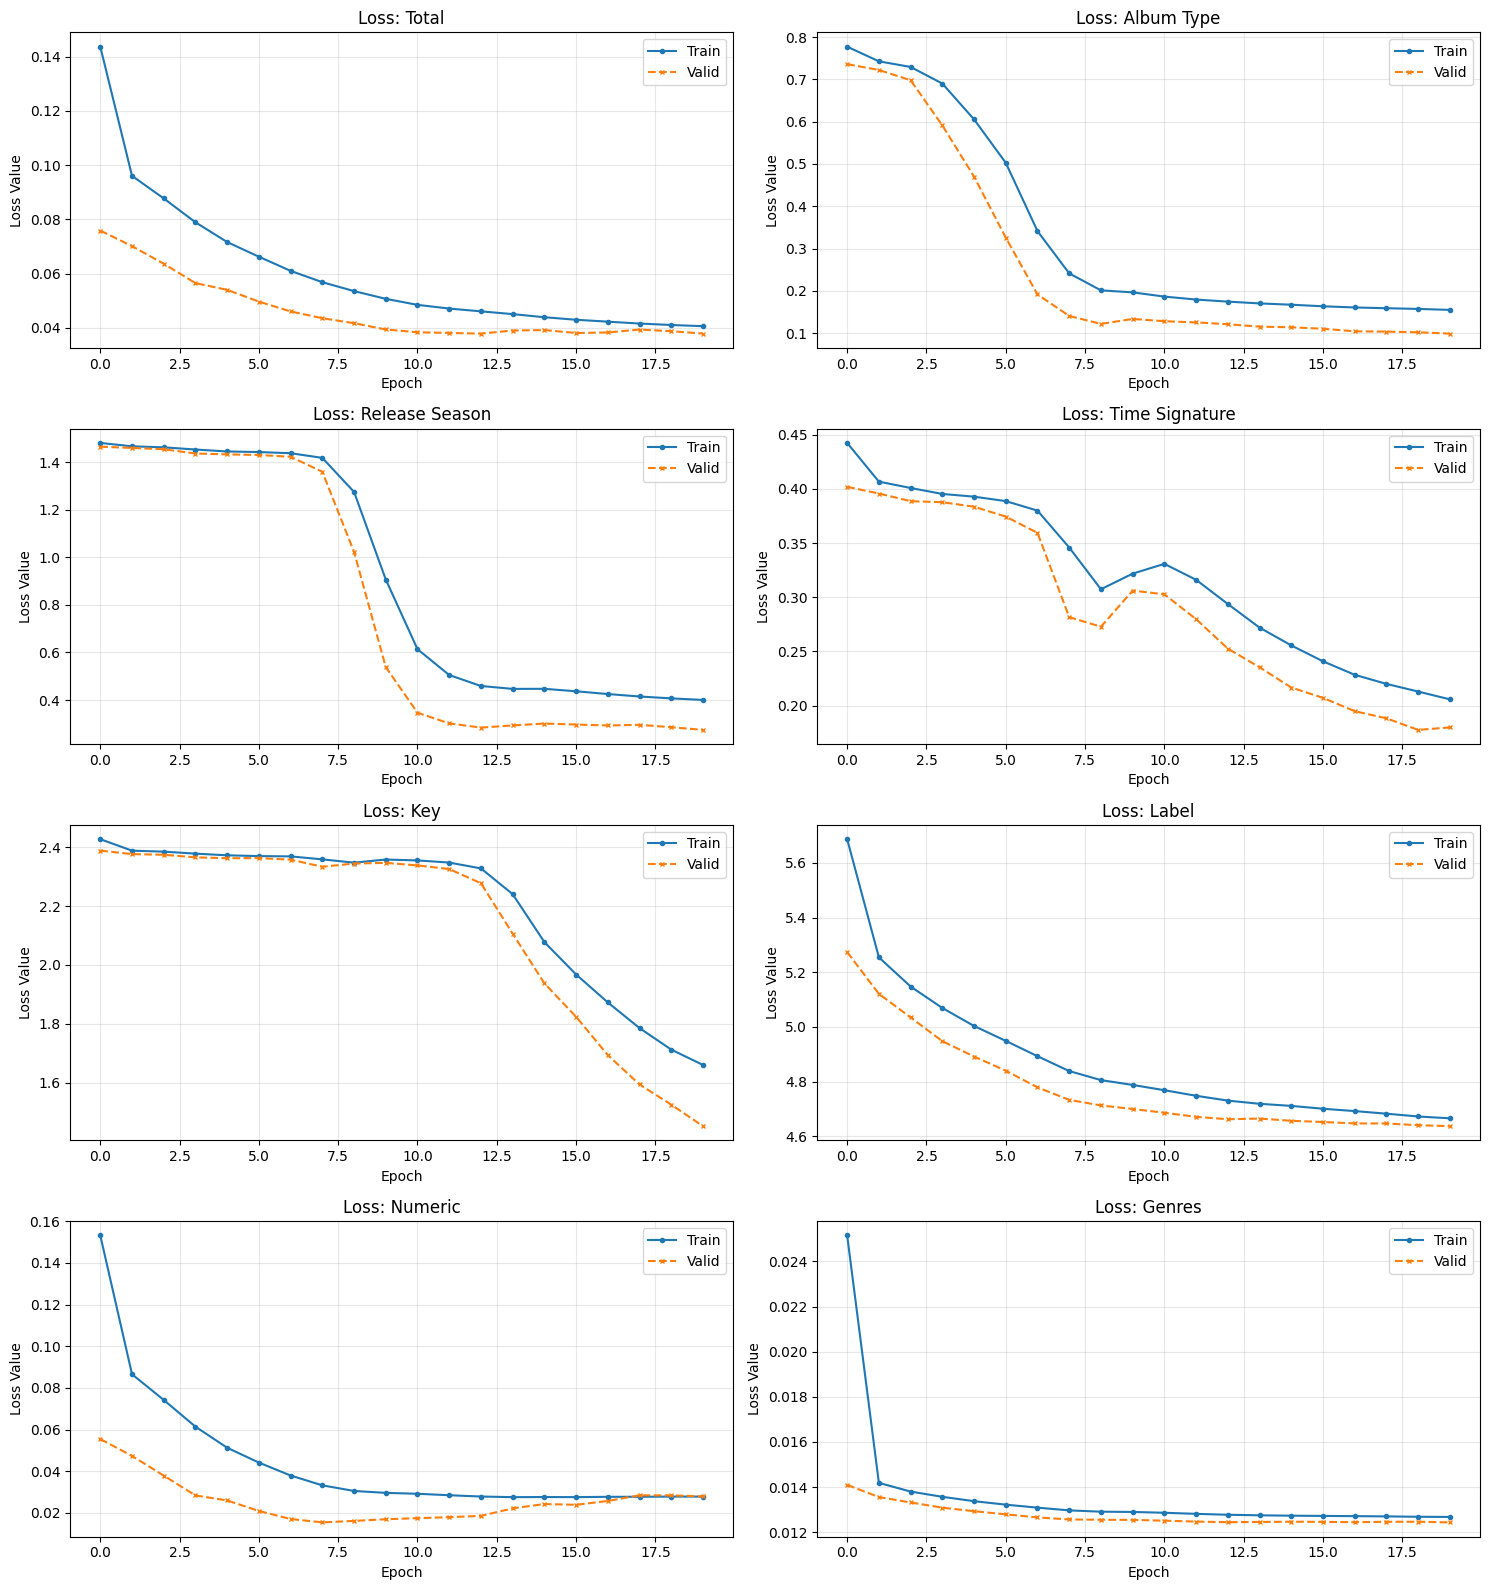

In [17]:
import matplotlib.pyplot as plt


def plot_training_results(history):
    metrics = list(history[0][0].keys())
    num_metrics = len(metrics)
    
    cols = 2
    rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        train_vals = [h[0][metric] for h in history]
        valid_vals = [h[1][metric] for h in history]
        
        ax = axes[i]
        ax.plot(train_vals, label="Train", marker="o", markersize=3)
        ax.plot(valid_vals, label="Valid", linestyle="--", marker="x", markersize=3)
        
        title = metric.replace("_", " ").title()
        ax.set_title(f"Loss: {title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")
        ax.legend()
        ax.grid(True, alpha=0.3)
        if train_vals[0] / (train_vals[-1] + 1e-9) > 100:
            ax.set_yscale("log")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Use it like this:
plot_training_results(history)

## Profiling

In [23]:
df_indexed = df.reset_index(drop=True)

inference_dataset = TrackDataset(df_indexed, label2idx, genre2idx)
inference_loader = DataLoader(
    inference_dataset, 
    batch_size=1024, 
    shuffle=False,  # critical!
    num_workers=20, 
    pin_memory=True, 
    collate_fn=collate_fn
)

Z = get_all_embeddings(model, inference_loader, device)

In [24]:
idx = 42
sim = F.cosine_similarity(Z[idx].unsqueeze(0), Z)
print(f"Self-sim: {sim[idx]:.4f}")  # expect 1.0000
print(df_indexed.iloc[idx][["artist_name", "track_name"]])

Self-sim: 1.0000
artist_name    Albin Lee Meldau
track_name          Discomforts
Name: 42, dtype: object


In [33]:
def recommend(artist, track, n=10):
    match = df_indexed[(df_indexed["artist_name"] == artist) & (df_indexed["track_name"] == track)]
    if match.empty: 
        return "Track not found."
    
    idx = match.index[0]  # Already positional since we reset_index(drop=True)
    query_vec = Z[idx].unsqueeze(0)
    sim = F.cosine_similarity(query_vec, Z)
    scores, top_indices = torch.topk(sim, k=n+1)
    print(scores)
    return df_indexed.iloc[top_indices[1:].cpu()][["artist_name", "track_name"]]

recommend("Radiohead", "Creep")

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000])


,artist_name,track_name
31052,Drakeo the Ruler,Go Crazy
52945,HVDES,Revelations
73108,Léo Ferré,L'affiche rouge
19697,Ice Cube,You Know How We Do It
81940,APO Hiking Society,Syotang Pa-Class
35514,JEON WOO SUNG,Reciting the Spell
87705,Maike Alan,O Tempo Não para
89989,国风新语,怎叹
20614,Eric B. & Rakim,Know The Ledge
12185,MC MONG,A resting place (Feat. Kim Young Heum)
